In [2]:
from os.path import join
import sys
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy")) 
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


In [4]:
def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of neighbors
        u_new = 0.25 * (
            u[1:-1, :-2] +
            u[1:-1, 2:] +
            u[:-2, 1:-1] +
            u[2:, 1:-1]
        )

        u_new_interior = u_new[interior_mask]

        delta = np.abs(
            u[1:-1, 1:-1][interior_mask] - u_new_interior
        ).max()

        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break

    return u

In [5]:
def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]

    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100

    return {
        "mean_temp": mean_temp,
        "std_temp": std_temp,
        "pct_above_18": pct_above_18,
        "pct_below_15": pct_below_15,
    }

In [5]:

LOAD_DIR = "./small_data/"

with open(join(LOAD_DIR, "building_ids.txt"), "r") as f:
    building_ids = f.read().splitlines()

#if len(sys.argv) < 2:
#    N = 1
#else:
#    N = int(sys.argv[1])

N = 2

building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype="bool")

for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations
MAX_ITER = 20000
ABS_TOL = 1e-4

all_u = np.empty_like(all_u0)

for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

# Print summary statistics
stat_keys = ["mean_temp", "std_temp", "pct_above_18", "pct_below_15"]

print("building_id, " + ", ".join(stat_keys))

for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid}, " + ", ".join(str(stats[k]) for k in stat_keys))

building_id, mean_temp, std_temp, pct_above_18, pct_below_15
10000, 14.012338788112752, 6.367431059312565, 30.941014791508444, 55.542295034537624
10009, 11.000135812436369, 5.811144379826625, 16.6712734948236, 74.9723590310584


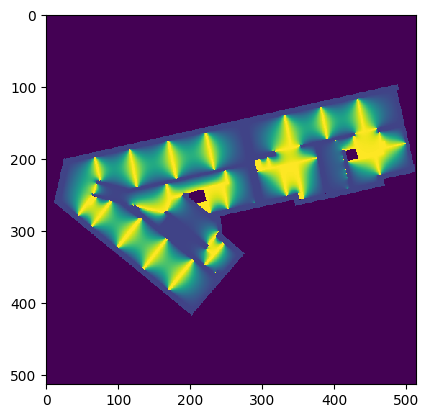

In [ ]:
u0, interior_mask = load_data(LOAD_DIR, '10000')
u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)

plt.imshow(u, interpolation='none')

In [ ]:
from multiprocessing.pool import Pool, ThreadPool

def main():
    LOAD_DIR = "./small_data/"

    with open(join(LOAD_DIR, "building_ids.txt"), "r") as f:
        building_ids = f.read().splitlines()

    N = 2
    building_ids = building_ids[:N]

    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype=bool)

    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    MAX_ITER = 20000
    ABS_TOL = 1e-4

    tasks = [
        (u0, interior_mask, MAX_ITER, ABS_TOL)
        for u0, interior_mask in zip(all_u0, all_interior_mask)
    ]

    with ThreadPool(1) as pool:
        all_u = pool.starmap(jacobi, tasks)

    stat_keys = ["mean_temp", "std_temp", "pct_above_18", "pct_below_15"]

    print("building_id, " + ", ".join(stat_keys))

    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid}, " + ", ".join(str(stats[k]) for k in stat_keys))

if __name__ == "__main__":
    main()

In [ ]:
import multiprocessing
import numpy as np
from os.path import join

#def main():
LOAD_DIR = "./small_data/"

with open(join(LOAD_DIR, "building_ids.txt"), "r") as f:
    building_ids = f.read().splitlines()

N = 4
building_ids = building_ids[:N]

all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype=bool)

for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

MAX_ITER = 20000
ABS_TOL = 1e-4

tasks = [
    (u0, interior_mask, MAX_ITER, ABS_TOL)
    for u0, interior_mask in zip(all_u0, all_interior_mask)
]


n_proc = 2
chunk_size = N//n_proc
pool = multiprocessing.Pool(n_proc)
all_u = [pool.apply_async(jacobi(u0, interior_mask, MAX_ITER, ABS_TOL), 
                (chunk_size,))
                for i in range(n_proc)]
print(r.get() for r in all_u)
#with Pool(2) as pool:
#    all_u = pool.starmap(jacobi, tasks)

stat_keys = ["mean_temp", "std_temp", "pct_above_18", "pct_below_15"]

print("building_id, " + ", ".join(stat_keys))

#for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
#    stats = summary_stats(u, interior_mask)
#    print(f"{bid}, " + ", ".join(str(stats[k]) for k in stat_keys))

#if __name__ == "__main__":
#    main()

chunk_size = 2
pool = <multiprocessing.pool.Pool state=RUN pool_size=2>
all_u
<generator object <genexpr> at 0x0000028CF6018EE0>
building_id, mean_temp, std_temp, pct_above_18, pct_below_15


In [17]:
print(r.get() for r in all_u)


<generator object <genexpr> at 0x0000028CF7D96CF0>


In [22]:
type(all_u)

list

In [23]:
all_u[0]